Part 1:

In [1]:
#1
import pandas as pd
import numpy as np
data = pd.read_csv('ForeignGifts_edu.csv')
data.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [2]:
#2
data['Gift Type'].value_counts()
data.columns

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='str')

There are 3 different types of gifts: Contracts, Monetary Gifts, and Real Estate

In [3]:
#3
countries_by_gift = data.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
countries_by_gift = countries_by_gift.sort_values()
countries_by_gift

Country of Giftor
ERITREA                  3
SLOVAKIA                20
CROATIA                 26
ST. LUCIA               50
IRAN                    80
                   ...    
BERMUDA          899593972
SAUDI ARABIA    1065205930
CHINA           1237952112
ENGLAND         1464906771
QATAR           2706240869
Name: Foreign Gift Amount, Length: 155, dtype: int64

In [4]:
data['Country of Giftor'].value_counts()

Country of Giftor
ENGLAND                  3655
CHINA                    2461
CANADA                   2344
JAPAN                    1896
SWITZERLAND              1676
                         ... 
ROMANIA                     1
TUNISIA                     1
ST. KITTS-NEVIS             1
MARSHAL ISLANDS (THE)       1
ANTIGUA                     1
Name: count, Length: 155, dtype: int64

In [5]:
average_gift = data.groupby('Country of Giftor')['Foreign Gift Amount'].mean()
average_gift.sort_values()

Country of Giftor
ERITREA      3.000000e+00
SLOVAKIA     2.000000e+01
CROATIA      2.600000e+01
IRAN         4.000000e+01
ST. LUCIA    5.000000e+01
                 ...     
JERSEY       3.064589e+06
ANTIGUA      3.435545e+06
QATAR        3.905109e+06
ECUADOR      3.985140e+06
BERMUDA      7.688837e+06
Name: Foreign Gift Amount, Length: 155, dtype: float64

In [6]:
uni_amounts = data.groupby('Institution Name')['Foreign Gift Amount'].sum()
uni_amounts.sort_values()


Institution Name
University of Jamestown                         500
University of Central Oklahoma               160288
University of California, Merced             182514
Metropolitan State University                235439
Beth Medrash Govoha of America               250000
                                            ...    
Yale University                           613441311
Massachusetts Institute of Technology     859071692
Harvard University                        954803610
Cornell University                       1289937761
Carnegie Mellon University               1477922504
Name: Foreign Gift Amount, Length: 318, dtype: int64

In [7]:
uni_gift_cts = data['Institution Name'].value_counts()
uni_gift_cts

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
                                               ... 
University of Wisconsin - Platteville             1
Des Moines Area Community College                 1
Beth Medrash Govoha of America                    1
Columbia Southern University                      1
Presidio Graduate School                          1
Name: count, Length: 318, dtype: int64

<Axes: ylabel='Institution Name'>

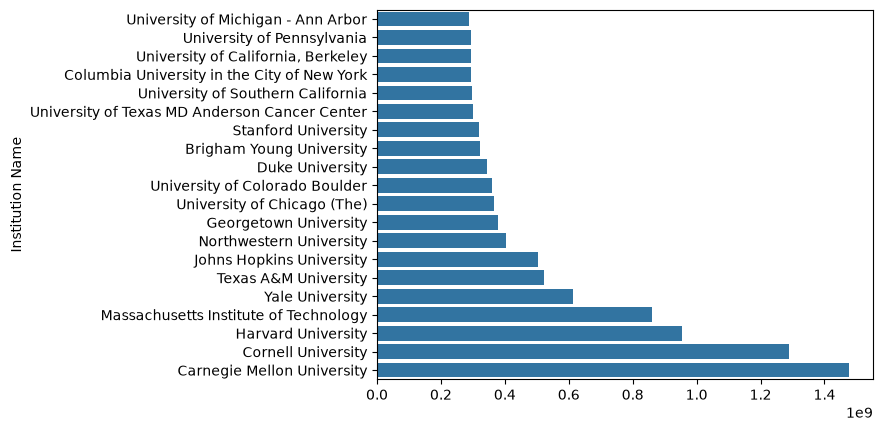

In [8]:
amts_sorted = uni_amounts.sort_values()
top_20 = amts_sorted[-20:]
top_20

import seaborn as sns
t20_plot = sns.barplot(x=top_20.values, y=top_20.index)
t20_plot

In [9]:
amt_mean = data['Foreign Gift Amount'].mean()
amt_mean

np.float64(588232.7172672832)

In [10]:
school_sums = data.groupby('Institution Name')['Foreign Gift Amount'].sum()
school_mean = school_sums.mean()
school_mean


np.float64(52202878.974842764)

In [11]:
amt_med = data['Foreign Gift Amount'].median()
amt_med

np.float64(94615.0)

In [12]:
data['Foreign Gift Amount'].max()

np.int64(99999999)

In [13]:
relationships = pd.crosstab(data['Country of Giftor'], data['Institution Name'])
relationships

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMERICAN SAMOA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANTIGUA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ARGENTINA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
WALES,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
data['Giftor Name'].value_counts()

Giftor Name
Saudi Arabian Cultural Mission         480
Human Frontier Science Program         287
Anonymous                              262
Qatar Foundation                       261
Novartis Pharmaceuticals Corp          251
                                      ... 
Light Year Holdings LTD                  1
Chia Tai TianQing Pharmaceutical Gr      1
BL Oncology Ltd                          1
Roche Products Limited                   1
Estate of Alfred Gertrud Sommerguth      1
Name: count, Length: 8993, dtype: int64

    1. Qatar donates the most
    2. England has donated the most frequently
    3. Bermuda has the largest gifts on average
    4. Carnegie Mellon receives the most in gifts
    5. UCLA has received the highest number of gifts
    6. The mean gift is $588,232 while the median is 94,615. These values are different because large outliers bring the mean up while the middle value (median) is just $94,615
    7. The maximum gift is $99,999,999
    8. Saudi Arabian Cultural Mission is the top giftor
    

In [15]:
pd.set_option('display.max_rows', None)
all_amounts = data.groupby('Institution Name')['Foreign Gift Amount'].sum()
all_amounts.sort_values()

Institution Name
University of Jamestown                                                 500
University of Central Oklahoma                                       160288
University of California, Merced                                     182514
Metropolitan State University                                        235439
Beth Medrash Govoha of America                                       250000
Jacksonville State University                                        250000
Bates College                                                        250000
Marquette University                                                 295048
Yeshiva University                                                   297397
California State University, Dominguez Hills                         299605
Wayne State University                                               299895
University of Portland                                               300000
University of Hawaii at Hilo                                         32